In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

## Задание 1
Загрузить данные из файла “insurance.csv”.

In [16]:
data = pd.read_csv('PR3/insurance.csv')

## Задание 2
С помощью метода describe() посмотреть статистику по данным.

In [17]:
data = pd.read_csv('PR3/insurance.csv')
print(data.describe());

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


## Задание 3
Построить гистограммы для числовых показателей.

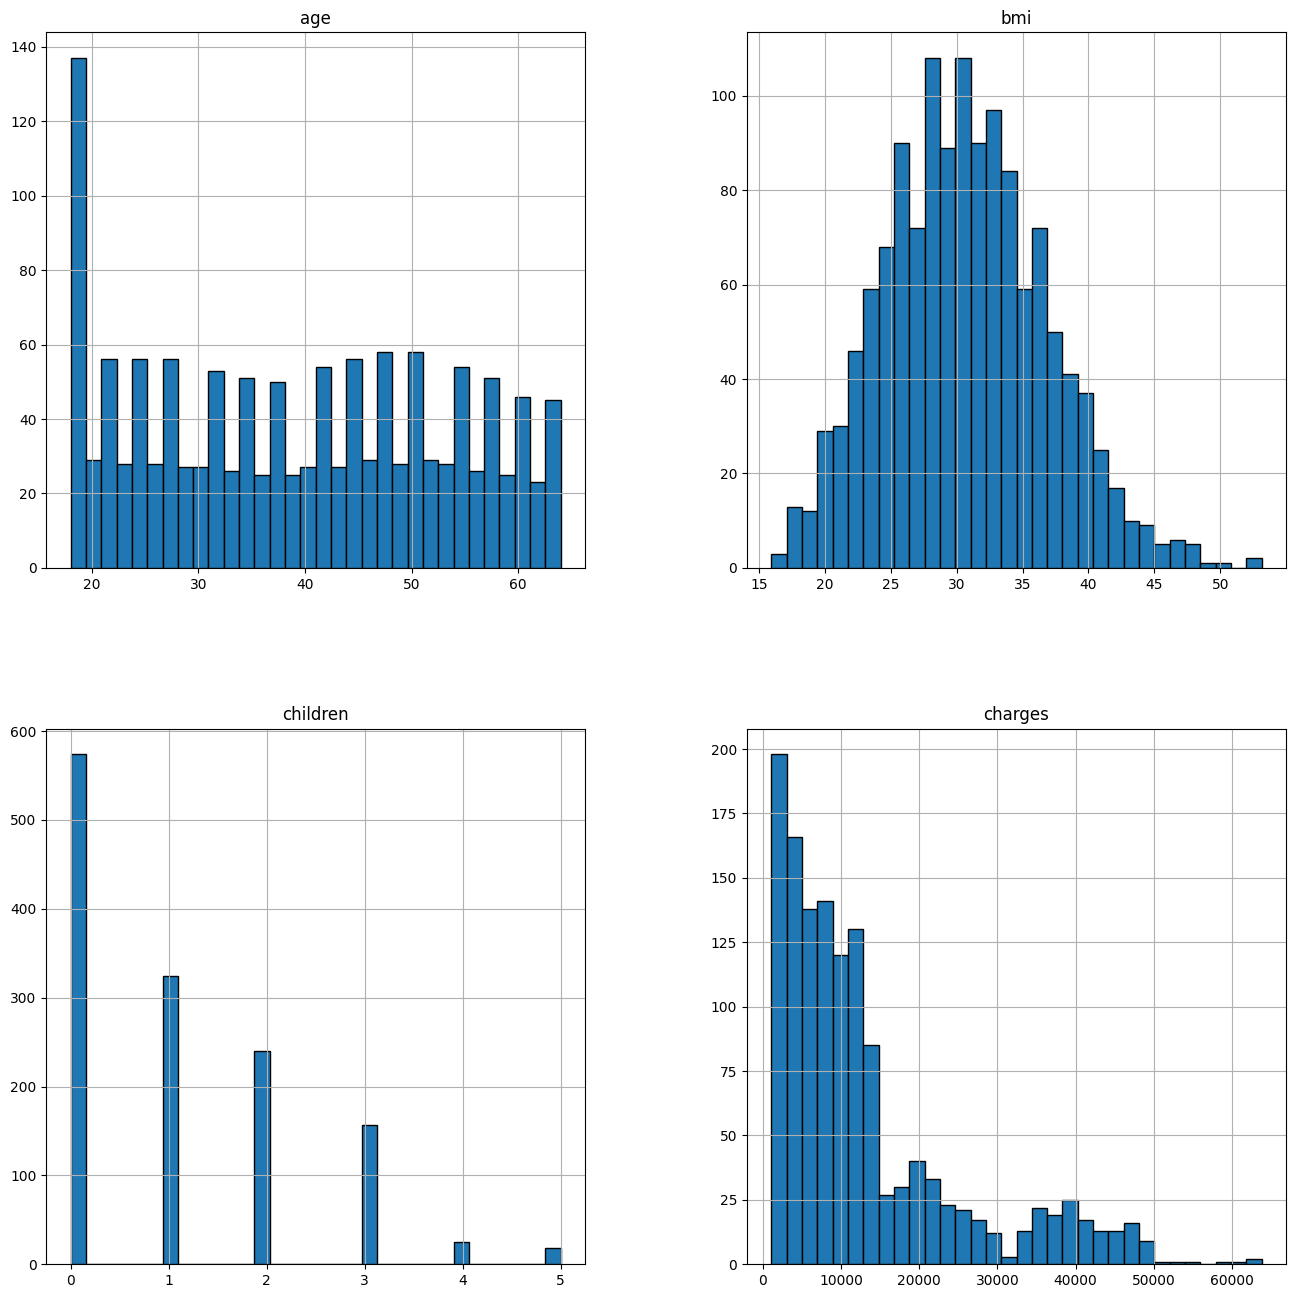

In [18]:
data = pd.read_csv('Pr3/insurance.csv')

col = ['age', 'bmi', 'children', 'charges']
data[col].hist(bins=32, figsize=(16, 16), edgecolor='black')
plt.show()

## Задание 4
Найти меры центральной тенденции и меры разброса для индекса массы тела (bmi) и расходов (charges). Отобразить результаты в виде текста и на гистограммах (3 вертикальные линии). Добавить легенду на графики.

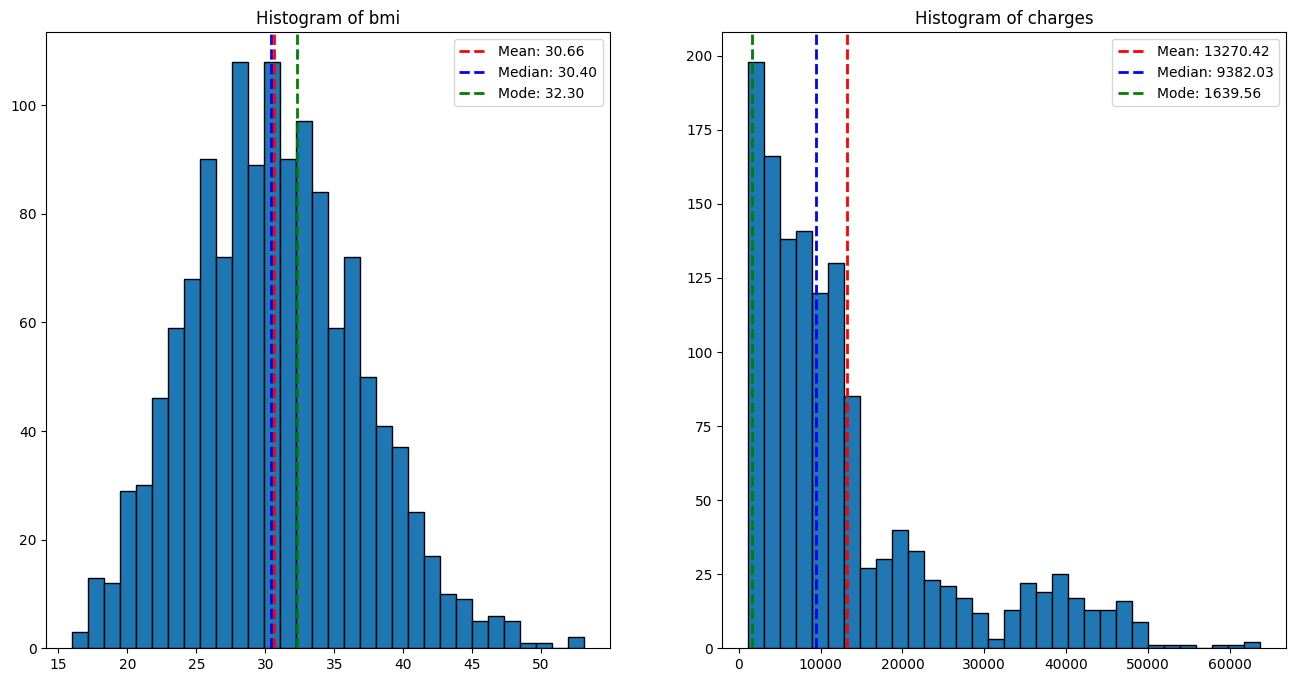

In [19]:
data = pd.read_csv('Pr3/insurance.csv')
col = ['bmi', 'charges']

mean, median, mode = {}, {}, {}

for i in range(0, 2):
    mean[i] = data[col[i]].mean()
    median[i] = data[col[i]].median()
    mode[i] = data[col[i]].mode()[0]

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

for i in range(0, 2):
    ax[i].hist(data[col[i]], bins=32, edgecolor='black')

    ax[i].axvline(mean[i], color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean[i]:.2f}')
    ax[i].axvline(median[i], color='blue', linestyle='dashed', linewidth=2, label=f'Median: {median[i]:.2f}')
    ax[i].axvline(mode[i], color='green', linestyle='dashed', linewidth=2, label=f'Mode: {mode[i]:.2f}')

    ax[i].set_title(f'Histogram of {col[i]}')
    ax[i].legend()

plt.show()


## Заданеи 5
Построить box-plot для числовых показателей. Названия графиков должны соответствовать названиям признаков.

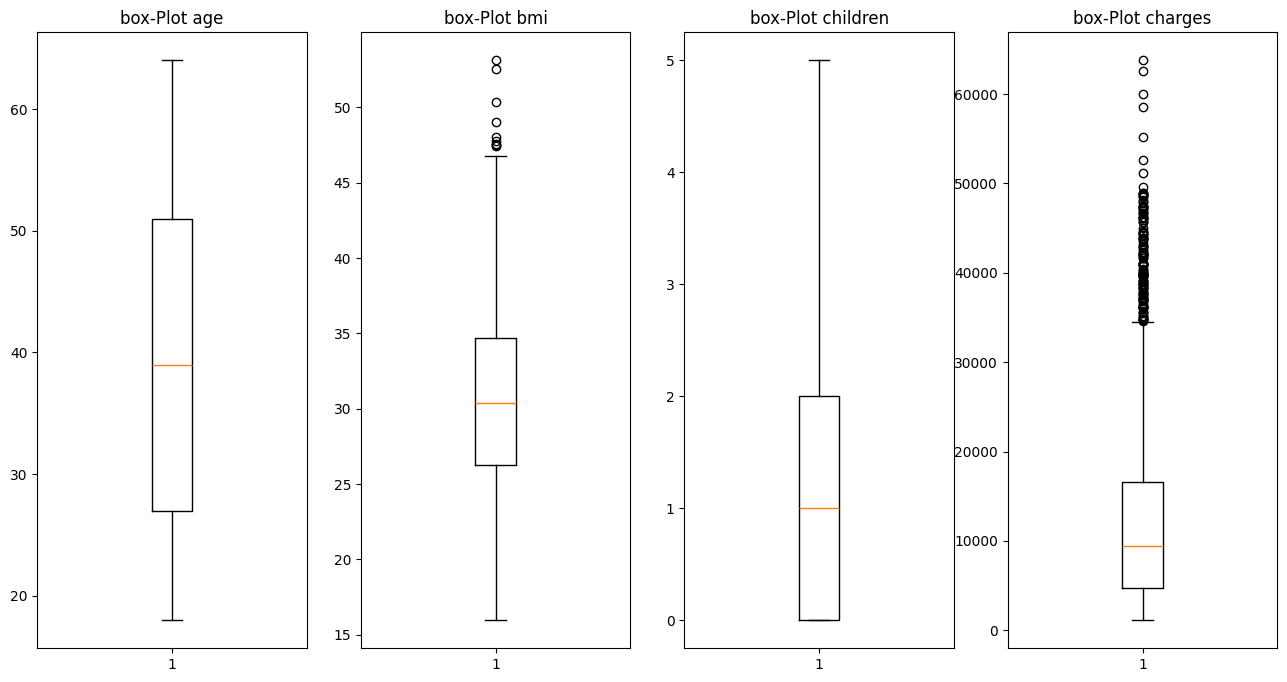

In [20]:
data = pd.read_csv('Pr3/insurance.csv')

col = ['age', 'bmi', 'children', 'charges']
fig, ax = plt.subplots(1, 4, figsize=(16, 8))

for i, j in enumerate(col):
    ax[i].boxplot(data[j])
    ax[i].set_title(f"box-Plot {j}")
    ax[i].set_label(j)

plt.show()

## Задание 6
Используя признак charges или imb, проверить, выполняется ли центральная предельная теорема. Использовать различные длины выборок n. Количество выборок = 300. Вывести результат в виде гистограмм. Найти  стандартное отклонение и среднее для полученных распределений.

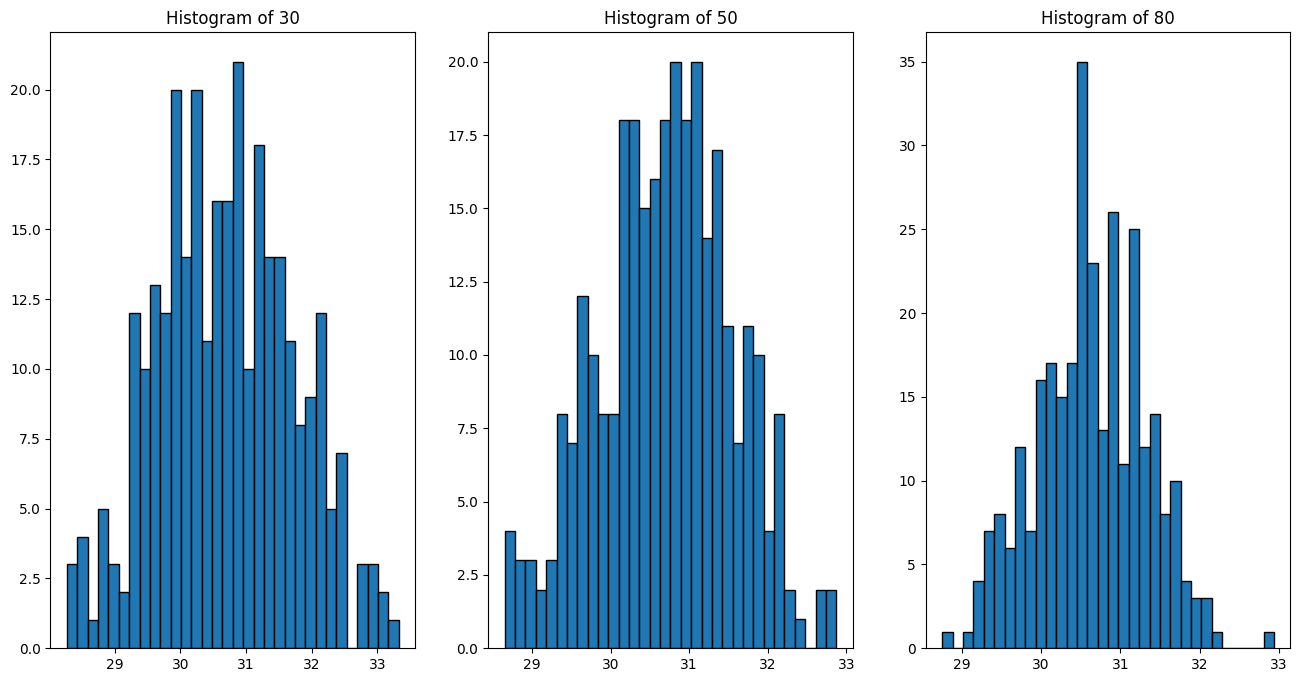

In [21]:
data = pd.read_csv('Pr3/insurance.csv')

samples = [30, 50, 80]
num = 300


def gen(data, sz, num):
    mean = [np.mean(np.random.choice(data, sz)) for _ in range(num)]
    return mean


means = [gen(data['bmi'], n, num) for n in samples]
fig, ax = plt.subplots(1, 3, figsize=(16, 8))

for i in range(0, 3):
    ax[i].hist(means[i], bins=32, edgecolor='black')
    ax[i].set_title(f'Histogram of {samples[i]}')

plt.show()

## Задание 7
Построить 95% и 99% доверительный интервал для среднего значения расходов и среднего значения индекса массы тела.

In [22]:
data = pd.read_csv('Pr3/insurance.csv')


def confidence_interval(data, confidence):
    n = len(data)
    mean = np.mean(data)
    std_err = stats.sem(data)
    interval = std_err * stats.t.ppf((1 + confidence) / 2., n - 1)
    return mean - interval, mean + interval


confidence_levels = [0.95, 0.99]
features = ['charges', 'bmi']

intervals = {feature: {f"{int(level * 100)}&": confidence_interval(data[feature], level) for level in confidence_levels}
             for feature in features}

for feature, conf_int in intervals.items():
    print(f"\n{feature.capitalize()}:")
    for level, interval in conf_int.items():
        print(f"{level}: {interval}")


Charges:
95&: (np.float64(12620.954034192644), np.float64(13919.890496089869))
99&: (np.float64(12416.429943203952), np.float64(14124.414587078561))

Bmi:
95&: (np.float64(30.336346903054107), np.float64(30.99044681891899))
99&: (np.float64(30.233355575431627), np.float64(31.09343814654147))


 ## Задание 8
Проверить распределения следующих признаков на нормальность: индекс массы тела, расходы. Сформулировать нулевую и альтернативную гипотезы. Для каждого признака использовать KS-тест и q-q plot.

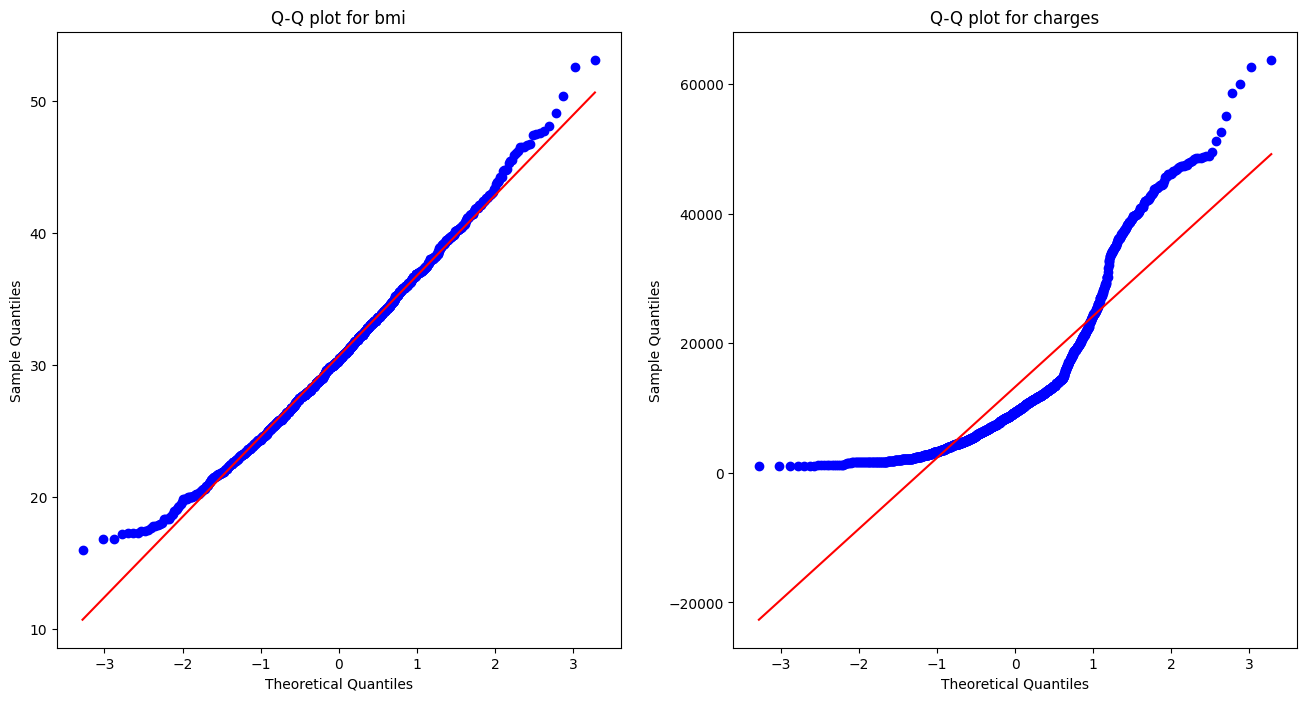

In [23]:
data = pd.read_csv('Pr3/insurance.csv')

features = ['bmi', 'charges']

fig, ax = plt.subplots(1, 2, figsize=(16, 8))

for i in range(len(features)):
    name = features[i]
    series = data[name]

    stats.probplot(series, dist="norm", plot=ax[i])
    ax[i].set_title(f"Q-Q plot for {name}")
    ax[i].set_xlabel("Theoretical Quantiles")
    ax[i].set_ylabel("Sample Quantiles")

plt.show()


## Задание 9
Загрузить данные из файла “ECDCCases.csv”.

In [24]:
data = pd.read_csv('Pr3/ECDCCases.csv')

## Задание 10
Проверить в данных наличие пропущенных значений. Вывести количество пропущенных значений в процентах. Удалить два признака, в которых больше всех пропущенных значений. Для оставшихся признаков обработать пропуски: для категориального признака использовать заполнение значением по умолчанию (например, «other»), для числового признака использовать заполнение медианным значением. Показать, что пропусков больше в данных нет.

In [25]:
data = pd.read_csv('Pr3/ECDCCases.csv')

mis_data = data.isnull().mean() * 100
print("Missing Data:", mis_data, sep='\n')

drop = mis_data.nlargest(2).index
data_clean = data.drop(columns=drop)

for col in data_clean.columns:
    if data_clean[col].dtype == 'object':
        data_clean[col] = data_clean[col].fillna('other')
    else:
        data_clean[col] = data_clean[col].fillna(data_clean[col].median())

mis_data = data_clean.isnull().mean() * 100
print("Missing Data after cleanup:", mis_data, sep='\n')

Missing Data:
dateRep                                                       0.000000
day                                                           0.000000
month                                                         0.000000
year                                                          0.000000
cases                                                         0.000000
deaths                                                        0.000000
countriesAndTerritories                                       0.000000
geoId                                                         0.444236
countryterritoryCode                                          0.198695
popData2019                                                   0.198695
continentExp                                                  0.000000
Cumulative_number_for_14_days_of_COVID-19_cases_per_100000    4.650750
dtype: float64
Missing Data after cleanup:
dateRep                    0.0
day                        0.0
month                      0.

## Задание 11
Посмотреть статистику по данным, используя describe(). Сделать выводы о том, какие признаки содержат выбросы. Посмотреть, для каких стран количество смертей в день превысило 3000 и сколько таких дней было.

In [26]:
data = pd.read_csv('Pr3/ECDCCases.csv')

drop = mis_data.nlargest(2).index
data_clean = data.drop(columns=drop)

print("Stats: ", data_clean.describe())

high_deaths = data_clean[data_clean['deaths'] > 3000]
countries_high_deaths = high_deaths['countriesAndTerritories'].unique()
days_with_high_deaths = high_deaths.shape[0]

print(f"Countries: {countries_high_deaths}")
print(f"Days: {days_with_high_deaths}")

Stats:                month          year          cases        deaths   popData2019  \
count  61904.000000  61904.000000   61904.000000  61904.000000  6.178100e+04   
mean       7.067104   2019.998918    1155.079026     26.053987  4.098628e+07   
std        2.954816      0.032881    6779.010824    131.222948  1.531246e+08   
min        1.000000   2019.000000   -8261.000000  -1918.000000  8.150000e+02   
25%        5.000000   2020.000000       0.000000      0.000000  1.293120e+06   
50%        7.000000   2020.000000      15.000000      0.000000  7.169456e+06   
75%       10.000000   2020.000000     273.000000      4.000000  2.851583e+07   
max       12.000000   2020.000000  234633.000000   4928.000000  1.433784e+09   

       Cumulative_number_for_14_days_of_COVID-19_cases_per_100000  
count                                       59025.000000           
mean                                           66.316369           
std                                           162.324550           

## Задание 12
Найти дублирование данных. Удалить дубликаты.

In [27]:
data = pd.read_csv('Pr3/ECDCCases.csv')

data_clean = data.drop_duplicates()

print(len(data) - len(data_clean))


4


## Задание 13
Загрузить данные из файла “bmi.csv”. Взять оттуда две выборки. Одна выборка – это индекс массы тела людей c региона northwest, вторая выборка – это индекс массы тела людей с региона southwest. Сравнить средние значения этих выборок, используя t-критерий Стьюдента. Предварительно проверить выборки на нормальность (критерий ШопироУилка) и на гомогенность дисперсии (критерий Бартлетта).

In [31]:
data = pd.read_csv('Pr3/bmi.csv')

data_northwest = data[data['region'] == 'northwest']['bmi']
data_southwest = data[data['region'] == 'southwest']['bmi']

shapito_northwest = stats.shapiro(data_northwest)
shapito_southwest = stats.shapiro(data_southwest)
print(f"Northwest p-Value {shapito_northwest[1]: .4f}")
print(f"Southwest p-Value {shapito_southwest[1]: .4f}")

balet_test = stats.bartlett(data_northwest, data_southwest)
print(f"Test: {balet_test[1]: .4f}")

t_test = stats.ttest_ind(data_northwest, data_southwest)
print(f"T-test: {t_test[1]: .4f}")

Northwest p-Value  0.4656
Southwest p-Value  0.3630
Test:  0.0652
T-test:  0.0011


## Задание 14
Кубик бросили 600 раз, получили следующие результаты:
С помощью критерия Хи-квадрат проверить, является ли полученное распределение равномерным. scipy.stats.chisquare().

In [34]:
freq = [97, 98, 109, 95, 97, 104]
expect = [600 / 6] * 6

stat, p_value = stats.chisquare(f_obs=freq, f_exp=expect)

print(f"Stat: {stat:4f}, p-Value: {p_value:4f}")

Stat: 1.440000, p-Value: 0.919888


## Задание 15
С помощью критерия Хи-квадрат проверить, являются ли переменные зависимыми.  Создать датафрейм, используя следующий код:
data = pd.DataFrame({'Женат': [89,17,11,43,22,1],
'Гражданский брак': [80,22,20,35,6,4],
'Не состоит в отношениях': [35,44,35,6,8,22]})
data.index = ['Полный рабочий день','Частичная занятость','Временно не
работает','На домохозяйстве','На пенсии','Учёба']
Использовать функцию scipy.stats.chi2_contingency(). Влияет ли семейное положение на занятость?

In [36]:
data = pd.DataFrame({
    "Женат": [89, 17, 11, 43, 22, 1],
    "Гражданский брак": [80, 22, 20, 35, 6, 4],
    "Не состоит в отношениях": [35, 44, 35, 6, 8, 22]
})
data.index = ["Полный pабочий день", "Частичная занятость", "Временно не работает", "На домохозяйстве", "На пенсии", "Учёба"]

stat, p_value, dof, expected = stats.chi2_contingency(data)

print(f"Statistic: {stat}")
print(f"P-Value: {p_value}")
print(f"DoF: {dof}")
print(f"Expected:\n{expected}")



Statistic: 122.29654948595365
P-Value: 1.7291616900960234e-21
DoF: 10
Expected:
[[74.664 68.136 61.2  ]
 [30.378 27.722 24.9  ]
 [24.156 22.044 19.8  ]
 [30.744 28.056 25.2  ]
 [13.176 12.024 10.8  ]
 [ 9.882  9.018  8.1  ]]
